In [2]:
from sklearn.metrics import mean_squared_error as mse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# creating the sample dataset
experience = [1.2,1.5,1.9,2.2,2.4,2.5,2.8,3.1,3.3,3.7,4.2,4.4]
salary = [1.7,2.4,2.3,3.1,3.7,4.2,4.4,6.1,5.4,5.7,6.4,6.2]
data = pd.DataFrame({ "salary" : salary, "experience" : experience })
print(data.head())

   salary  experience
0     1.7         1.2
1     2.4         1.5
2     2.3         1.9
3     3.1         2.2
4     3.7         2.4


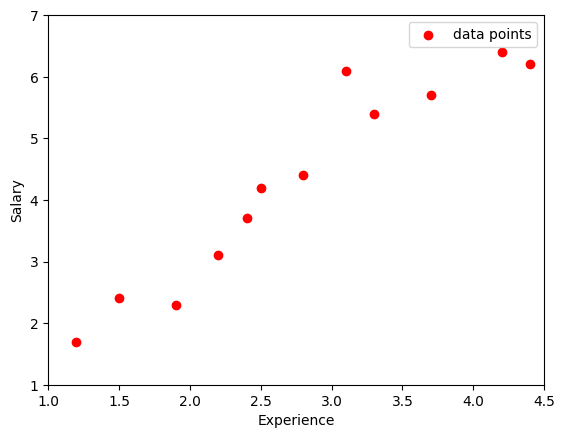

In [4]:
# plotting the data

plt.scatter(data.experience, data.salary, color = 'red', label = 'data points')
plt.xlim(1,4.5)
plt.ylim(1,7)
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.legend()

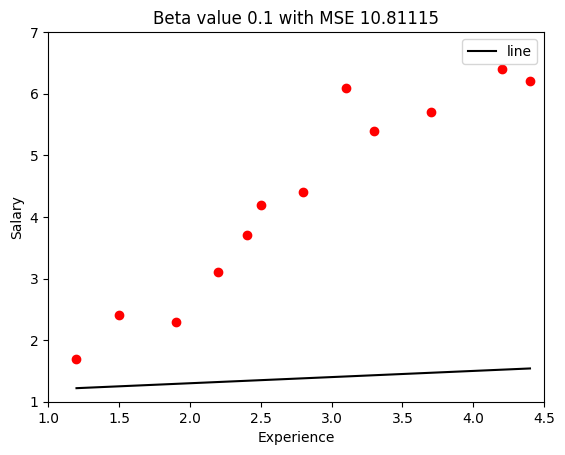

In [5]:
# making lines for different Values of Beta 0.1, 0.8, 1.5
beta = 0.1

# keeping intercept constant
b = 1.1

# to store predicted points
line1 = []

# generating predictions for every data point
for i in range(len(data)):
    line1.append(data.experience[i]*beta + b)

# Plotting the line
plt.scatter(data.experience, data.salary, color = 'red')
plt.plot(data.experience, line1, color = 'black', label = 'line')
plt.xlim(1,4.5)
plt.ylim(1,7)
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.legend()

MSE = mse(data.salary, line1)

plt.title("Beta value "+str(beta)+" with MSE "+ str(MSE))

MSE = mse(data.salary, line1)

In [6]:
MSE

10.81115

In [11]:
from sklearn.metrics import mean_squared_error as mse # Assuming you use sklearn

def Error(Beta, data):
    # b is constant
    b = 1.1
    salary = []
    experience = data.experience

    # Loop to calculate predict salary variables
    for i in range(len(data.experience)):
        tmp = data.experience[i] * Beta + b
        salary.append(tmp)

    # Calculate MSE
    MSE = mse(data.salary, salary)
    return MSE

In [12]:
# Range of slopes from 0 to 1.5 with increment of 0.01

slope = [i/100 for i in range(0,150)]
Cost = []
for i in slope:
    cost = Error( Beta = i, data = data)
    Cost.append(cost)

In [14]:
# Arranging in DataFrame

Cost_table = pd.DataFrame({
'Beta' : slope,
'Cost' : Cost
})

Cost_table.head()

,Beta,Cost
0,0.00,12.791667
1,0.01,12.585876
2,0.02,12.381806
3,0.03,12.179455
4,0.04,11.978824


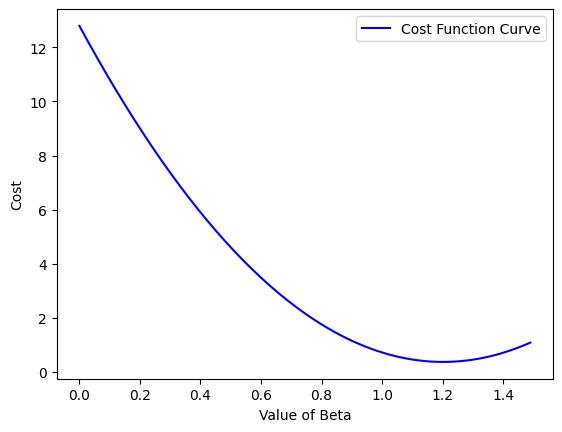

In [15]:
# plotting the cost values corresponding to every value of Beta

plt.plot(Cost_table.Beta, Cost_table.Cost, color = 'blue', label = 'Cost Function Curve')
plt.xlabel('Value of Beta')
plt.ylabel('Cost')
plt.legend()

----------------------------------------
SECTION 1: BASIC CALCULATION
----------------------------------------
   Actual ($k)  Predicted ($k)  Error (Diff)  Squared Error
0          200             210           -10            100
1          250             240            10            100
2          300             320           -20            400
3          350             340            10            100
4          400             430           -30            900

Calculations:
Sum of Squared Errors (SSE): 1600
Mean Squared Error (MSE):    320.00 (Units: $k squared)
Root Mean Sq Error (RMSE):   17.89 (Units: $k)
----------------------------------------

SECTION 2: SENSITIVITY TO OUTLIERS
----------------------------------------
Original MSE: 320.00  ->  With Outlier: 15266.67 (Increased by 47.7x)
Original RMSE: 17.89 ->  With Outlier: 123.56 (Increased by 6.9x)
Notice how MSE explodes much more dramatically than RMSE relative to its scale.
----------------------------------------


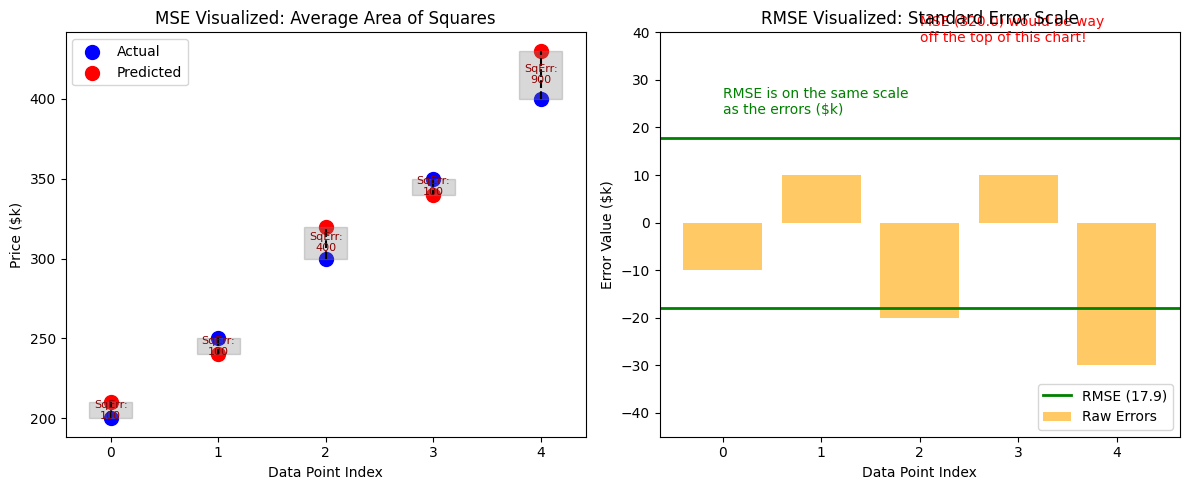

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def mse_vs_rmse_demo():
    # 1. Setup Synthetic Data
    # Imagine we are predicting house prices (in $1000s)
    actual_prices = np.array([200, 250, 300, 350, 400])
    predicted_prices = np.array([210, 240, 320, 340, 430])

    # 2. Calculate Differences (Errors)
    errors = actual_prices - predicted_prices
    squared_errors = errors ** 2

    # 3. Calculate MSE and RMSE
    mse_val = np.mean(squared_errors)
    rmse_val = np.sqrt(mse_val)

    # --- SECTION 1: Basic Comparison ---
    print("-" * 40)
    print("SECTION 1: BASIC CALCULATION")
    print("-" * 40)
    df = pd.DataFrame({
        'Actual ($k)': actual_prices,
        'Predicted ($k)': predicted_prices,
        'Error (Diff)': errors,
        'Squared Error': squared_errors
    })
    print(df)
    print("\nCalculations:")
    print(f"Sum of Squared Errors (SSE): {np.sum(squared_errors)}")
    print(f"Mean Squared Error (MSE):    {mse_val:.2f} (Units: $k squared)")
    print(f"Root Mean Sq Error (RMSE):   {rmse_val:.2f} (Units: $k)")
    print("-" * 40)

    # --- SECTION 2: The "Outlier" Effect ---
    # Let's introduce one bad prediction (an outlier)
    actual_outlier = np.append(actual_prices, 500)
    pred_outlier = np.append(predicted_prices, 800) # Massive error of 300

    errors_out = actual_outlier - pred_outlier
    mse_out = np.mean(errors_out ** 2)
    rmse_out = np.sqrt(mse_out)

    print("\nSECTION 2: SENSITIVITY TO OUTLIERS")
    print("-" * 40)
    print(f"Original MSE: {mse_val:.2f}  ->  With Outlier: {mse_out:.2f} (Increased by {mse_out/mse_val:.1f}x)")
    print(f"Original RMSE: {rmse_val:.2f} ->  With Outlier: {rmse_out:.2f} (Increased by {rmse_out/rmse_val:.1f}x)")
    print("Notice how MSE explodes much more dramatically than RMSE relative to its scale.")
    print("-" * 40)

    # --- SECTION 3: Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Visualizing MSE (Areas of Squares)
    ax1.set_title("MSE Visualized: Average Area of Squares")
    ax1.scatter(np.arange(len(actual_prices)), actual_prices, color='blue', label='Actual', s=100)
    ax1.scatter(np.arange(len(predicted_prices)), predicted_prices, color='red', label='Predicted', s=100)

    # Draw squares to represent MSE
    for i, (act, pred) in enumerate(zip(actual_prices, predicted_prices)):
        diff = abs(act - pred)
        # Draw a square patch centered on the x-value
        rect = plt.Rectangle((i - 0.2, min(act, pred)), 0.4, diff, color='gray', alpha=0.3)
        ax1.add_patch(rect)
        ax1.plot([i, i], [act, pred], color='black', linestyle='--')
        ax1.text(i, (act+pred)/2, f"SqErr:\n{diff**2}", ha='center', va='center', fontsize=8, color='darkred')

    ax1.set_xticks(np.arange(len(actual_prices)))
    ax1.set_xlabel("Data Point Index")
    ax1.set_ylabel("Price ($k)")
    ax1.legend()

    # Plot 2: Visualizing RMSE (Scale Comparison)
    ax2.set_title("RMSE Visualized: Standard Error Scale")

    # Plot errors as bars
    ax2.bar(np.arange(len(errors)), errors, color='orange', alpha=0.6, label='Raw Errors')

    # Plot RMSE and MSE levels
    ax2.axhline(y=rmse_val, color='green', linestyle='-', linewidth=2, label=f'RMSE ({rmse_val:.1f})')
    ax2.axhline(y=-rmse_val, color='green', linestyle='-', linewidth=2)

    # Attempt to plot MSE on the same graph usually fails because the scale is too big
    # We just annotate it to show the difference
    ax2.text(0, rmse_val + 5, "RMSE is on the same scale\nas the errors ($k)", color='green')
    ax2.text(2, rmse_val + 20, f"MSE ({mse_val:.1f}) would be way\noff the top of this chart!", color='red', fontsize=10)

    ax2.set_xlabel("Data Point Index")
    ax2.set_ylabel("Error Value ($k)")
    ax2.legend(loc='lower right')
    ax2.set_ylim(min(errors)*1.5, max(errors)*4) # Make room for text

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    mse_vs_rmse_demo()

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, SGDRegressor, HuberRegressor, QuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [18]:
# 1. Load and Prepare Data
print("Loading California Housing Dataset...")
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

Loading California Housing Dataset...


In [20]:
# We'll use just one feature 'MedInc' (Median Income) to make visualization easy (2D plots)
X_simple = X[['MedInc']].values
y_simple = y

In [21]:
np.random.seed(42)
outlier_indices = np.random.choice(len(y), 50, replace=False)
y_simple[outlier_indices] = 10.0

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Data Loaded. Artificial outliers added to simulate real-world noise.
------------------------------
Training MSE Model (Linear Regression)...
MSE Model Coefficient: 0.80
Training MAE Model (SGDRegressor)...
MAE Model Coefficient: 0.83
Training Huber Model...
Huber Model Coefficient: 0.83
------------------------------
Generating Visualization...


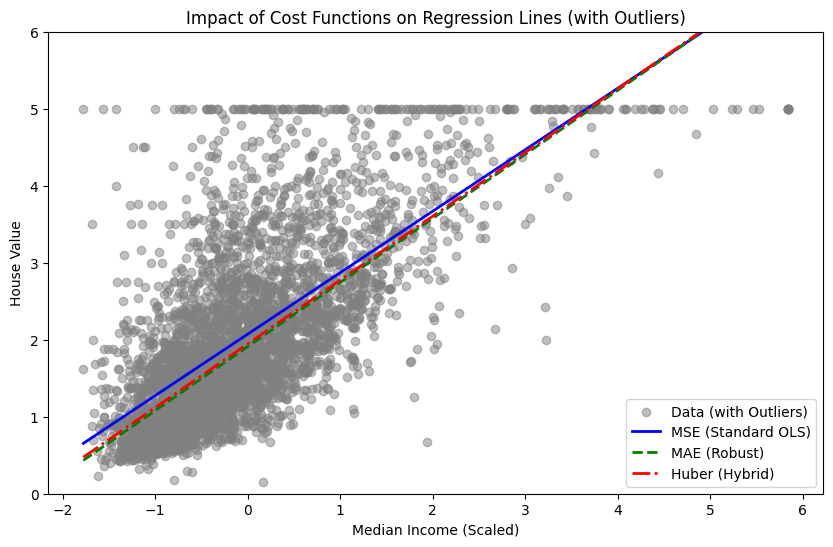

------------------------------
Performance Metrics (Test Set):
          Model  Test MSE  Test MAE
0  MSE (Linear)  1.467248  0.717029
1     MAE (SGD)  1.528250  0.702035
2         Huber  1.510669  0.702630
------------------------------
Note: The MSE model will likely have higher error metrics on the main cluster because it sacrificed accuracy to chase the outliers.


In [24]:
print("Data Loaded. Artificial outliers added to simulate real-world noise.")
print("-" * 30)

# ---------------------------------------------------------
# 1. Mean Squared Error (MSE) - The Standard Choice
# ---------------------------------------------------------
# Behavior: Minimizes squared error. Pulls the line towards outliers to reduce massive squared errors.
print("Training MSE Model (Linear Regression)...")
mse_model = LinearRegression()
mse_model.fit(X_train_scaled, y_train)
y_pred_mse = mse_model.predict(X_test_scaled)
print(f"MSE Model Coefficient: {mse_model.coef_[0]:.2f}")

# ---------------------------------------------------------
# 2. Mean Absolute Error (MAE) - The Robust Choice
# ---------------------------------------------------------
# Behavior: Minimizes absolute distance. Outliers contribute linearly, not quadratically.
# Using SGDRegressor with loss='epsilon_insensitive' and epsilon=0 approximates L1 loss minimization.
print("Training MAE Model (SGDRegressor)...")
mae_model = SGDRegressor(loss='epsilon_insensitive', epsilon=0, random_state=42)
mae_model.fit(X_train_scaled, y_train)
y_pred_mae = mae_model.predict(X_test_scaled)
print(f"MAE Model Coefficient: {mae_model.coef_[0]:.2f}")

# ---------------------------------------------------------
# 3. Huber Loss - The Hybrid Choice
# ---------------------------------------------------------
# Behavior: Quadratic for small errors, linear for large errors. Robust but stable.
print("Training Huber Model...")
huber_model = HuberRegressor(epsilon=1.35)
huber_model.fit(X_train_scaled, y_train)
y_pred_huber = huber_model.predict(X_test_scaled)
print(f"Huber Model Coefficient: {huber_model.coef_[0]:.2f}")

# ---------------------------------------------------------
# 4. Visualization & Comparison
# ---------------------------------------------------------
print("-" * 30)
print("Generating Visualization...")

plt.figure(figsize=(10, 6))

# Plot Raw Data
plt.scatter(X_test_scaled, y_test, color='gray', alpha=0.5, label='Data (with Outliers)')

# Generate a range of X values for plotting fit lines
x_range = np.linspace(X_test_scaled.min(), X_test_scaled.max(), 100).reshape(-1, 1)

# Plot fit lines
plt.plot(x_range, mse_model.predict(x_range), color='blue', linewidth=2, label='MSE (Standard OLS)')
plt.plot(x_range, mae_model.predict(x_range), color='green', linewidth=2, linestyle='--', label='MAE (Robust)')
plt.plot(x_range, huber_model.predict(x_range), color='red', linewidth=2, linestyle='-.', label='Huber (Hybrid)')

plt.title("Impact of Cost Functions on Regression Lines (with Outliers)")
plt.xlabel("Median Income (Scaled)")
plt.ylabel("House Value")
plt.legend()
plt.ylim(0, 6) # Zoom in on the main data cluster to see the fit better
plt.show()

# ---------------------------------------------------------
# 5. Performance Metrics
# ---------------------------------------------------------
print("-" * 30)
print("Performance Metrics (Test Set):")

results = pd.DataFrame({
    'Model': ['MSE (Linear)', 'MAE (SGD)', 'Huber'],
    'Test MSE': [
        mean_squared_error(y_test, y_pred_mse),
        mean_squared_error(y_test, y_pred_mae),
        mean_squared_error(y_test, y_pred_huber)
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_mse),
        mean_absolute_error(y_test, y_pred_mae),
        mean_absolute_error(y_test, y_pred_huber)
    ]
})

print(results)
print("-" * 30)
print("Note: The MSE model will likely have higher error metrics on the main cluster because it sacrificed accuracy to chase the outliers.")